In [1]:
import h5py
import numpy as np
import pandas as pd
import random
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import corner

from scipy import stats
from astroML.utils import completeness_contamination
from astroML.classification import GMMBayes

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score, 
    recall_score, 
    precision_score, 
    roc_curve, 
    roc_auc_score, 
    auc, 
    confusion_matrix, 
    average_precision_score,
    ConfusionMatrixDisplay
)
import tensorflow
from tensorflow import keras

2026-05-13 21:46:57.729666: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Can a computern learn if we're going to detect a GW?

In [2]:
with h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r') as file:
    
    keys = list(file.keys())
    print(keys)
    
    data = {}
    for key in keys:
        data[key] = file[key][:]

total_samples = len(data['det'])
print (f"Total samples:{total_samples}")

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']
Total samples:20000000


In [3]:
# Possibility of downsampling
N_samples = total_samples // 1

idx = np.random.choice(total_samples, N_samples, replace=False)

par_keys = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'ra', 'iota', 'psi', 'z'] # remove snr
lab_keys = ['det']

# Create X and y 
X = np.stack([data[k][idx] for k in par_keys], axis=1)
y = data['det'][idx].astype(int)

# Split between train and test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=52)

# Split between train and validation (No cross validation inside the neural network)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=52)


# Rescale the data
X_mean = X_train.mean(axis=0, keepdims=True)
X_mean_full = X_train_full.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_std_full = X_train_full.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_train_full = (X_train_full - X_mean_full) / X_std_full
X_val = (X_val - X_mean) / X_std
X_test= (X_test - X_mean_full) / X_std_full


print(len(X_train))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)


12800000
(12800000, 13)
(3200000, 13)
(4000000, 13)


In [4]:
keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tensorflow.random.set_seed(42)

Create a first MLP model

In [5]:

model = keras.models.Sequential([
   keras.layers.InputLayer(input_shape=[X_train.shape[1]]), 
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=1, activation='sigmoid')
])

print(model.summary())

/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
# For binary classification, we use 'binary_crossentropy'
model.compile(
    loss="binary_crossentropy", 
    optimizer="adam", #default value 0.001
    metrics=[keras.metrics.Precision(name='precision'),
        keras.metrics.AUC(curve='PR', name='pr_auc')]
)

Train the model

In [7]:
clf = model.fit(
    X_train, y_train, 
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=1024
)

#default values of batch size=32 is too small (weight must be modify too often and so the fit is slower)

Epoch 1/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0819 - pr_auc: 0.9547 - precision: 0.8889 - val_loss: 0.0592 - val_pr_auc: 0.9768 - val_precision: 0.9304
Epoch 2/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.0685 - pr_auc: 0.9672 - precision: 0.9039 - val_loss: 0.0575 - val_pr_auc: 0.9780 - val_precision: 0.9264
Epoch 3/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0675 - pr_auc: 0.9681 - precision: 0.9054 - val_loss: 0.0565 - val_pr_auc: 0.9790 - val_precision: 0.9276
Epoch 4/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.0659 - pr_auc: 0.9695 - precision: 0.9076 - val_loss: 0.0547 - val_pr_auc: 0.9808 - val_precision: 0.9361
Epoch 5/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0650 - pr_auc: 0.9703 - precision: 0.9097 - val_loss: 0.0542 - val_pr_auc: 0.9813 - val_precision: 0.9422
Epoch 6/20
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.0647 - pr_auc: 0.9706 - precision: 0.9101 - val_loss: 0.0530 - val_p

Plot how AUC PR score changes in function of the epoch

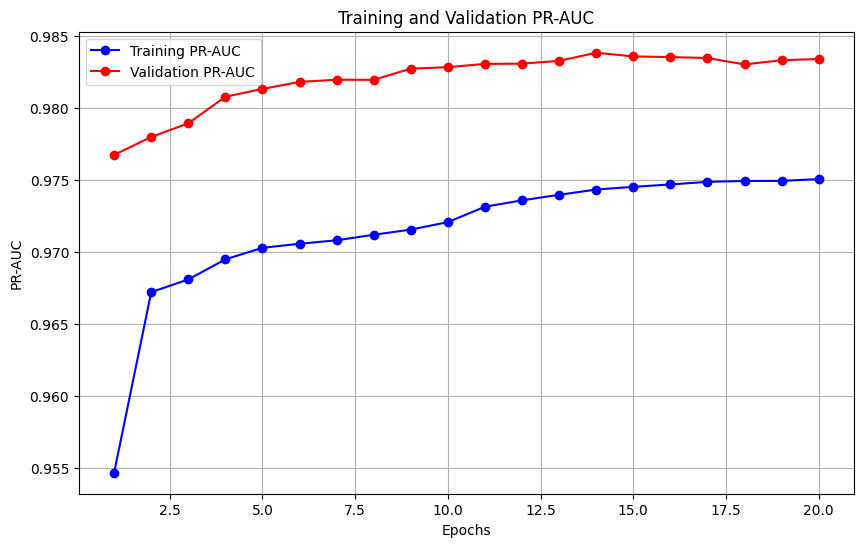

In [8]:
# Extract the data from the 'clf' object (one for each epoch)
train_auc = clf.history['pr_auc']
val_auc = clf.history['val_pr_auc']
epochs = range(1, len(train_auc) + 1)

#Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_auc, 'bo-', label='Training PR-AUC')
plt.plot(epochs, val_auc, 'ro-', label='Validation PR-AUC')

plt.title('Training and Validation PR-AUC')
plt.xlabel('Epochs')
plt.ylabel('PR-AUC')
plt.legend()
plt.grid(True)

plt.show()

Start by plotting the prediction of 10 sample from test set (just to visualize some results)

In [9]:
idx10 = np.random.choice(np.arange(len(y_test)), size=10, replace=False)
X_new = X_test[idx10]
y_true_10 = y_test[idx10]

# Prediction
y_proba_10 = model.predict(X_new, verbose=0).flatten()
y_pred_10 = (y_proba_10 > 0.5).astype(int)

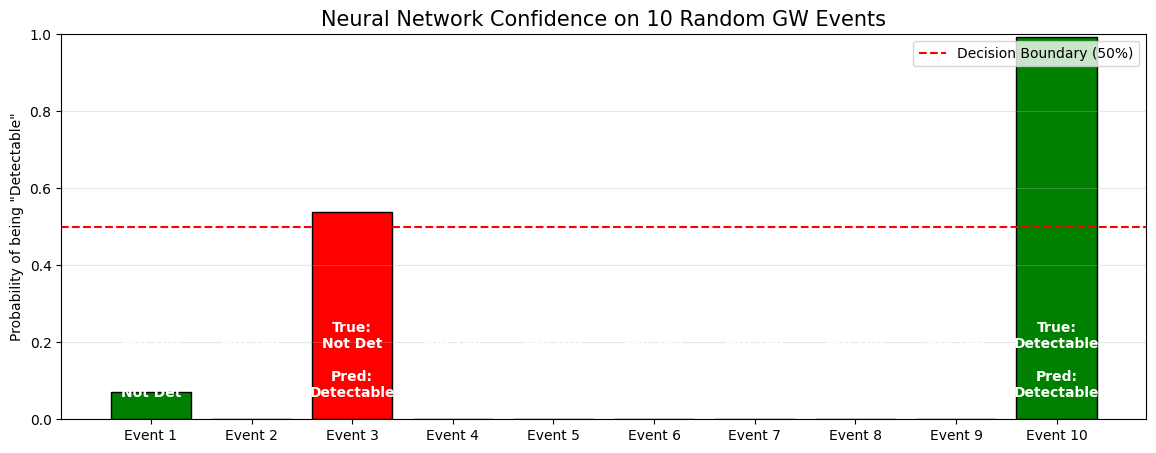

In [10]:
# Plot result for the 10 sample
gw_labels = {0: "Not Det", 1: "Detectable"}

plt.figure(figsize=(14, 5))

# Colorbars: Green if the prediction matches reality, Red if it's an error
colors = ['green' if true == pred else 'red' 
          for true, pred in zip(y_true_10, y_pred_10)]

bars = plt.bar(range(10), y_proba_10, color=colors, edgecolor='black')
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision Boundary (50%)')

for i, bar in enumerate(bars):
    actual = gw_labels[y_true_10[i]]
    pred = gw_labels[y_pred_10[i]]
    plt.text(bar.get_x() + bar.get_width()/2, 0.05, 
             f"True:\n{actual}\n\nPred:\n{pred}", 
             ha='center', va='bottom', color='white', fontweight='bold', fontsize=10)

plt.title('Neural Network Confidence on 10 Random GW Events', fontsize=15)
plt.ylabel('Probability of being "Detectable"')
plt.xticks(range(10), [f"Event {i+1}" for i in range(10)])
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

Now do prediction for the all test set

In [11]:
# Prediction
y_proba = model.predict(X_test, verbose=0).flatten()
y_pred = (y_proba > 0.5).astype(int)


Confusion matrix for the all test set

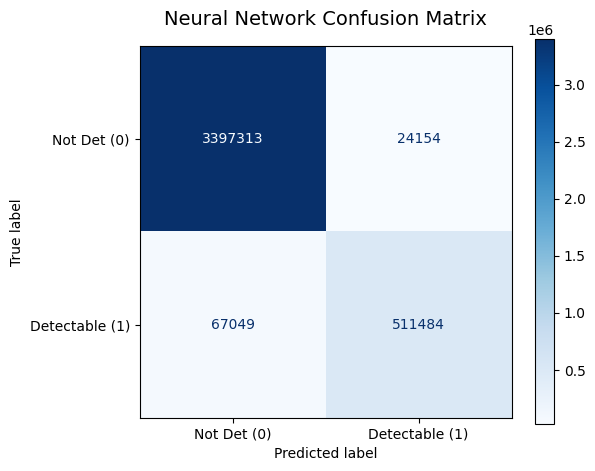

In [12]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)


disp.plot(cmap="Blues", values_format="d", ax=plt.gca()) 
plt.title("Neural Network Confusion Matrix", fontsize=14, pad=15)
plt.show()


# Now let's try to improve the neural network Precision

Start by using different combination of layers and unit

In [13]:
# Define Early Stopping to prevent wasting time on bad models
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_pr_auc', 
    patience=3, 
    mode='max',
    restore_best_weights=True
)

In [14]:
# Define different architectures
architectures = [
    [32, 16],          
    [64, 32],          
    [128, 64, 32],     
    [256, 128, 64]     
]

results = {}

for config in architectures:
    model_name = " -> ".join(map(str, config))
    print(f"\nTraining Model: {model_name}")
    
    keras.backend.clear_session()
    
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]])) # first layer (input) same for each model
    
    for units in config:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(0.3)) #fixed 0.3 dropout
    
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    # Compilation
    model.compile(
        loss="binary_crossentropy", 
        optimizer="adam", # default value of lr=0.001
        metrics=[keras.metrics.AUC(curve='PR', name='pr_auc')]
    )
    
    # Train 
    history = model.fit(
        X_train, y_train, 
        epochs=10, 
        validation_data=(X_val, y_val), 
        verbose=0,
        batch_size=1024,
        callbacks=[early_stop]
    )
    

    val_pr_auc = max(history.history['val_pr_auc'])
    results[model_name] = val_pr_auc
    print(f"Max Validation PR-AUC: {val_pr_auc:.4f}")

# Find the best configuration
best_config = max(results, key=results.get)
print(f"\nBest configuration {best_config} with {results[best_config]:.4f} PR-AUC")

best_arch = [int(x) for x in best_config.split(" -> ")]




Training Model: 32 -> 16


/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Max Validation PR-AUC: 0.9686

Training Model: 64 -> 32
Max Validation PR-AUC: 0.9850

Training Model: 128 -> 64 -> 32
Max Validation PR-AUC: 0.9909

Training Model: 256 -> 128 -> 64
Max Validation PR-AUC: 0.9935

Best configuration 256 -> 128 -> 64 with 0.9935 PR-AUC


Optimize the learning rate

In [15]:
learning_rates_to_test = [0.01, 0.001, 0.0001, 0.00001]
lr_results = {}
baseline_dropout = 0.3 # Same dropout as before

for lr in learning_rates_to_test:
    keras.backend.clear_session()
    np.random.seed(42)
    tensorflow.random.set_seed(42)
    
    # Dynamically build the model using best configuration of previous cell
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]]))
    for units in best_arch:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(baseline_dropout))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    custom_adam = keras.optimizers.Adam(learning_rate=lr)
    model.compile(loss="binary_crossentropy", optimizer=custom_adam, metrics=[keras.metrics.AUC(curve='PR', name='pr_auc')])

    history = model.fit(X_train, y_train, epochs=20, batch_size=1024, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
    
    lr_results[lr] = max(history.history['val_pr_auc'])
    print(f"LR: {lr:.5f} | Max Val PR-AUC: {lr_results[lr]:.4f}")

best_lr = max(lr_results, key=lr_results.get)
print(f"\nBest Learning Rate {best_lr}\n")

LR: 0.01000 | Max Val PR-AUC: 0.9864
LR: 0.00100 | Max Val PR-AUC: 0.9926
LR: 0.00010 | Max Val PR-AUC: 0.9910
LR: 0.00001 | Max Val PR-AUC: 0.9582

Best Learning Rate 0.001



Optimize dropout rate

In [16]:
dropout_rates_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
dropout_results = {}

for rate in dropout_rates_to_test:
    keras.backend.clear_session()
    np.random.seed(42)
    tensorflow.random.set_seed(42)
    
    # # Dynamically build the model using best configuration of previous cell
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]]))
    for units in best_arch:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(rate))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    custom_adam = keras.optimizers.Adam(learning_rate=best_lr)
    model.compile(loss="binary_crossentropy", optimizer=custom_adam, metrics=[keras.metrics.AUC(curve='PR', name='pr_auc')])
    
    history = model.fit(X_train, y_train, epochs=20, batch_size=1024, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
    
    dropout_results[rate] = max(history.history['val_pr_auc'])
    print(f"Dropout: {rate:.1f} | Max Val PR-AUC: {dropout_results[rate]:.4f}")

best_dropout = max(dropout_results, key=dropout_results.get)
print(f"\nBest Dropout Rate {best_dropout}\n")

Dropout: 0.1 | Max Val PR-AUC: 0.9971
Dropout: 0.2 | Max Val PR-AUC: 0.9934
Dropout: 0.3 | Max Val PR-AUC: 0.9925
Dropout: 0.4 | Max Val PR-AUC: 0.9912
Dropout: 0.5 | Max Val PR-AUC: 0.9894
Dropout: 0.6 | Max Val PR-AUC: 0.9871

Best Dropout Rate 0.1



Train the model with the best parameters

In [17]:
# Final training of best model with best params
keras.backend.clear_session()
np.random.seed(42)
tensorflow.random.set_seed(42)

# Build the ultimate model
best_model = keras.models.Sequential()
best_model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]]))
for units in best_arch:
    best_model.add(keras.layers.Dense(units, activation='relu'))
    best_model.add(keras.layers.Dropout(best_dropout))
best_model.add(keras.layers.Dense(1, activation='sigmoid'))

custom_adam = keras.optimizers.Adam(learning_rate=best_lr)
best_model.compile(loss="binary_crossentropy", optimizer=custom_adam, metrics=["accuracy", keras.metrics.AUC(curve='PR', name='pr_auc')])

history = best_model.fit(X_train, y_train, epochs=40, batch_size=1024, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1)

# Get final predictions on the unseen Test set
y_proba_final = best_model.predict(X_test, verbose=0).flatten()
y_pred_final = (y_proba_final > 0.5).astype(int)

Epoch 1/40
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - accuracy: 0.9793 - loss: 0.0474 - pr_auc: 0.9839 - val_accuracy: 0.9853 - val_loss: 0.0331 - val_pr_auc: 0.9924
Epoch 2/40
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 81s 6ms/step - accuracy: 0.9842 - loss: 0.0355 - pr_auc: 0.9906 - val_accuracy: 0.9867 - val_loss: 0.0301 - val_pr_auc: 0.9936
Epoch 3/40
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 81s 6ms/step - accuracy: 0.9850 - loss: 0.0338 - pr_auc: 0.9915 - val_accuracy: 0.9872 - val_loss: 0.0290 - val_pr_auc: 0.9941


Plot the confusion matrix

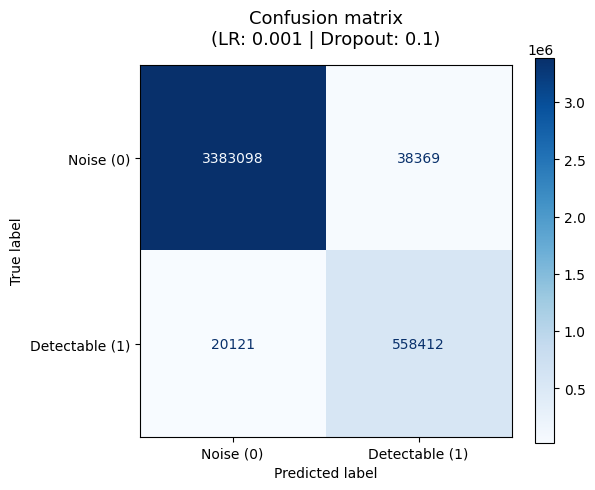

In [18]:
# Plot matrix
cm_best = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best, 
    display_labels=["Noise (0)", "Detectable (1)"]
)

disp.plot(cmap="Blues", values_format="d", ax=plt.gca()) 
plt.title(f"Confusion matrix\n(LR: {best_lr} | Dropout: {best_dropout})", fontsize=13, pad=15)
plt.grid(False) # Ensure the grid doesn't overlap the matrix
plt.show()

Now increase the threshold to 0.8 to decrease the false positives

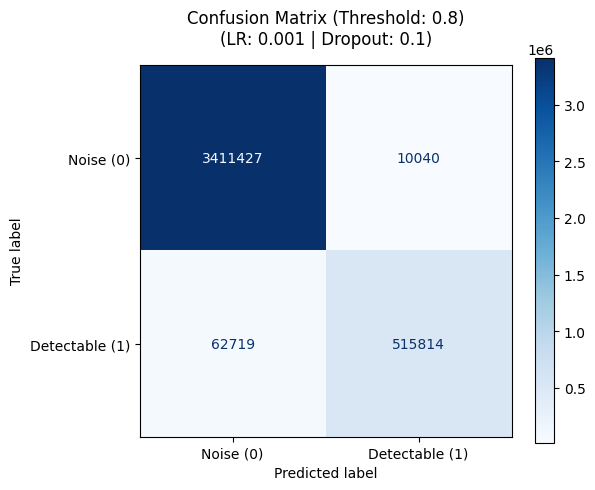

In [19]:
# Set the custom threshold
threshold = 0.8
y_pred_threshold = (y_proba_final > threshold).astype(int)


cm_best = confusion_matrix(y_test, y_pred_threshold)

#Plot
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best, 
    display_labels=["Noise (0)", "Detectable (1)"]
)

disp.plot(cmap="Blues", values_format="d", ax=plt.gca()) 

plt.title(f"Confusion Matrix (Threshold: {threshold})\n(LR: {best_lr} | Dropout: {best_dropout})", 
          fontsize=12, pad=15)

plt.grid(False)
plt.show()

Report the metrics

In [20]:
# Calculate metrics for standard threshold (0.5)
y_pred_05 = (y_proba_final > 0.5).astype(int)
acc_05 = accuracy_score(y_test, y_pred_05)
prec_05 = precision_score(y_test, y_pred_05)
rec_05 = recall_score(y_test, y_pred_05)

# Calculate metrics for high-purity threshold (0.8)
y_pred_08 = (y_proba_final > 0.8).astype(int)
acc_08 = accuracy_score(y_test, y_pred_08)
prec_08 = precision_score(y_test, y_pred_08)
rec_08 = recall_score(y_test, y_pred_08)

final_roc_auc = roc_auc_score(y_test, y_proba_final)
final_pr_auc = average_precision_score(y_test, y_proba_final)


print(f"{'Metric':<15} | {'Threshold 0.5':<15} | {'Threshold 0.8':<15}")
print("-" * 45)
print(f"{'Accuracy':<15} | {acc_05:<15.4f} | {acc_08:<15.4f}")
print(f"{'Precision':<15} | {prec_05:<15.4f} | {prec_08:<15.4f}")
print(f"{'Recall':<15} | {rec_05:<15.4f} | {rec_08:<15.4f}")
print("-" * 45)
print(f"{'ROC-AUC':<15} | {final_roc_auc:<33.4f}")
print(f"{'PR-AUC':<15} | {final_pr_auc:<33.4f}")


Metric          | Threshold 0.5   | Threshold 0.8  
---------------------------------------------
Accuracy        | 0.9854          | 0.9818         
Precision       | 0.9357          | 0.9809         
Recall          | 0.9652          | 0.8916         
---------------------------------------------
ROC-AUC         | 0.9987                           
PR-AUC          | 0.9926                           


Perform the final training on the full training set 

In [21]:



keras.backend.clear_session()
np.random.seed(42)
tensorflow.random.set_seed(42)

best_model = keras.models.Sequential()
best_model.add(keras.layers.InputLayer(input_shape=[X_train_full.shape[1]]))
for units in best_arch:
    best_model.add(keras.layers.Dense(units, activation='relu'))
    best_model.add(keras.layers.Dropout(best_dropout))
best_model.add(keras.layers.Dense(1, activation='sigmoid'))

custom_adam = keras.optimizers.Adam(learning_rate=best_lr)
best_model.compile(loss="binary_crossentropy", optimizer=custom_adam, metrics=["accuracy", keras.metrics.AUC(curve='PR', name='pr_auc')])

# no validation and no early stopping.
best_model.fit(
    X_train_full, y_train_full, 
    epochs=20,
    batch_size=1024, 
    verbose=1
)

/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/20
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 96s 6ms/step - accuracy: 0.9803 - loss: 0.0451 - pr_auc: 0.9854
Epoch 2/20
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 96s 6ms/step - accuracy: 0.9846 - loss: 0.0348 - pr_auc: 0.9910
Epoch 3/20
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 98s 6ms/step - accuracy: 0.9852 - loss: 0.0332 - pr_auc: 0.9918
Epoch 4/20
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 99s 6ms/step - accuracy: 0.9857 - loss: 0.0322 - pr_auc: 0.9923
Epoch 5/20
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 99s 6ms/step - accuracy: 0.9860 - loss: 0.0314 - pr_auc: 0.9926
Epoch 6/20
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 101s 6ms/step - accuracy: 0.9863 - loss: 0.0309 - pr_auc: 0.9928
Epoch 7/20
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 99s 6ms/step - accuracy: 0.9865 - loss: 0.0303 - pr_auc: 0.9931
Epoch 8/20
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 99s 6ms/step - accuracy: 0.9867 - loss: 0.0300 - pr_auc: 0.9933
Epoch 9/20
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 99s 6ms/step - accuracy: 0.9869 - loss: 0.0296 - pr_auc: 0.9934
Epoch 10/20
15625/15625 ━━━

Predict on test set

In [22]:

y_proba_final = best_model.predict(X_test, verbose=0).flatten()

y_pred_05 = (y_proba_final > 0.5).astype(int)
y_pred_08 = (y_proba_final > 0.8).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05)
cm_08 = confusion_matrix(y_test, y_pred_08)



 Plot the confusion matrices

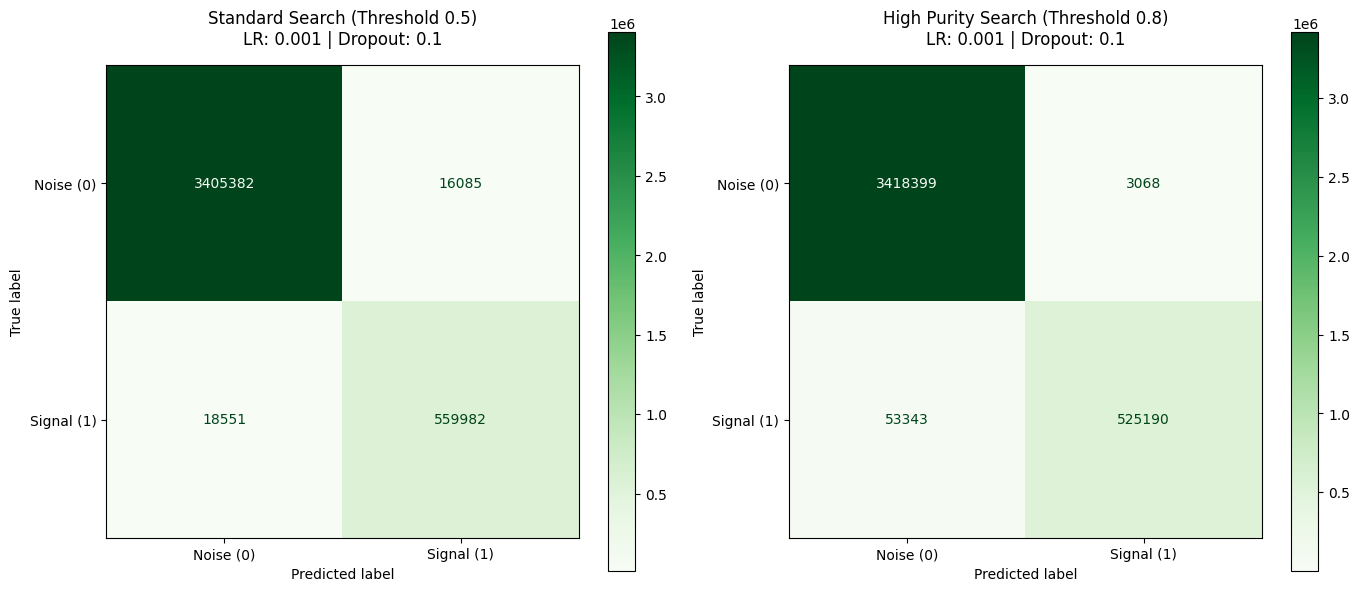

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Threshold 0.5
disp_05 = ConfusionMatrixDisplay(confusion_matrix=cm_05, display_labels=["Noise (0)", "Signal (1)"])
disp_05.plot(cmap="Greens", values_format="d", ax=axes[0])
axes[0].set_title(f"Standard Search (Threshold 0.5)\nLR: {best_lr} | Dropout: {best_dropout}", fontsize=12, pad=15)
axes[0].grid(False)

# Plot Threshold 0.8
disp_08 = ConfusionMatrixDisplay(confusion_matrix=cm_08, display_labels=["Noise (0)", "Signal (1)"])
disp_08.plot(cmap="Greens", values_format="d", ax=axes[1])
axes[1].set_title(f"High Purity Search (Threshold 0.8)\nLR: {best_lr} | Dropout: {best_dropout}", fontsize=12, pad=15)
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [24]:
# Calculate metrics for standard threshold (0.5)
y_pred_05 = (y_proba_final > 0.5).astype(int)
acc_05 = accuracy_score(y_test, y_pred_05)
prec_05 = precision_score(y_test, y_pred_05)
rec_05 = recall_score(y_test, y_pred_05)

# Calculate metrics for threshold (0.8)
y_pred_08 = (y_proba_final > 0.8).astype(int)
acc_08 = accuracy_score(y_test, y_pred_08)
prec_08 = precision_score(y_test, y_pred_08)
rec_08 = recall_score(y_test, y_pred_08)

final_roc_auc = roc_auc_score(y_test, y_proba_final)
final_pr_auc = average_precision_score(y_test, y_proba_final)


print(f"{'Metric':<15} | {'Threshold 0.5':<15} | {'Threshold 0.8':<15}")
print("-" * 45)
print(f"{'Accuracy':<15} | {acc_05:<15.4f} | {acc_08:<15.4f}")
print(f"{'Precision':<15} | {prec_05:<15.4f} | {prec_08:<15.4f}")
print(f"{'Recall':<15} | {rec_05:<15.4f} | {rec_08:<15.4f}")
print("-" * 45)
print(f"{'ROC-AUC':<15} | {final_roc_auc:<33.4f}")
print(f"{'PR-AUC':<15} | {final_pr_auc:<33.4f}")

Metric          | Threshold 0.5   | Threshold 0.8  
---------------------------------------------
Accuracy        | 0.9913          | 0.9859         
Precision       | 0.9721          | 0.9942         
Recall          | 0.9679          | 0.9078         
---------------------------------------------
ROC-AUC         | 0.9995                           
PR-AUC          | 0.9972                           
